--- First 5 Rows ---
   Unnamed: 0       Date       Close        High         Low        Open  \
0        2701  3/23/2021  220.720001  225.933334  219.169998  225.256668   
1        2702  3/24/2021  210.089996  222.673340  210.036667  222.636673   
2        2703  3/25/2021  213.463333  215.166672  203.166672  204.333328   
3        2704  3/26/2021  206.236664  214.606674  199.963333  213.956665   
4        2705  3/29/2021  203.763336  205.493332  198.673340  205.213333   

      Volume  
0   91475700  
1  101385600  
2  117674700  
3  101558400  
4   85911000  

--- Initial Data Types ---
Unnamed: 0      int64
Date              str
Close         float64
High          float64
Low           float64
Open          float64
Volume          int64
dtype: object

--- Data Types after Conversion ---
Unnamed: 0             int64
Date          datetime64[us]
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume                 in

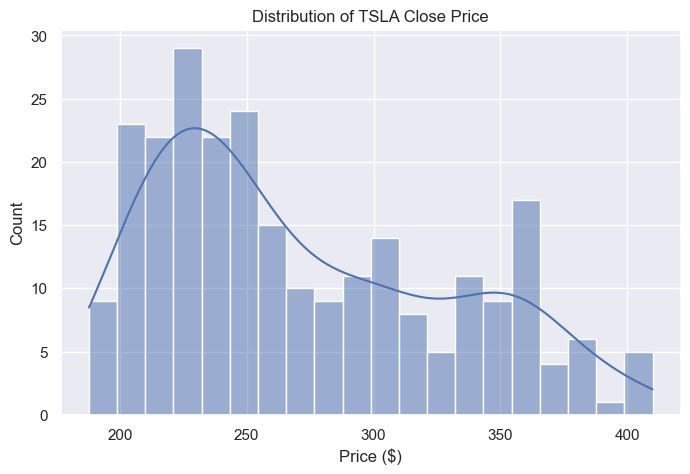

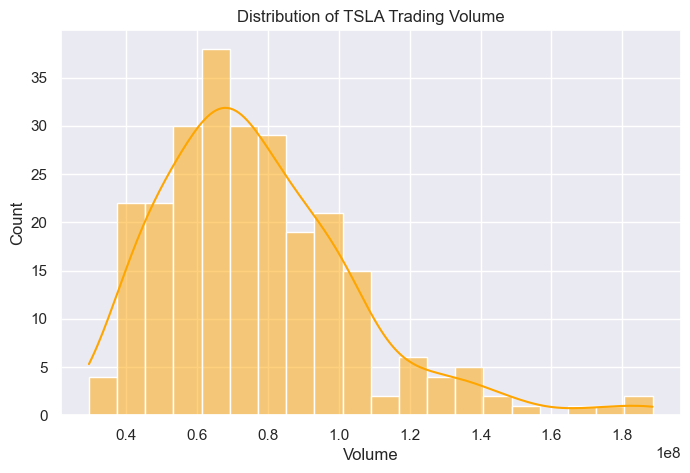

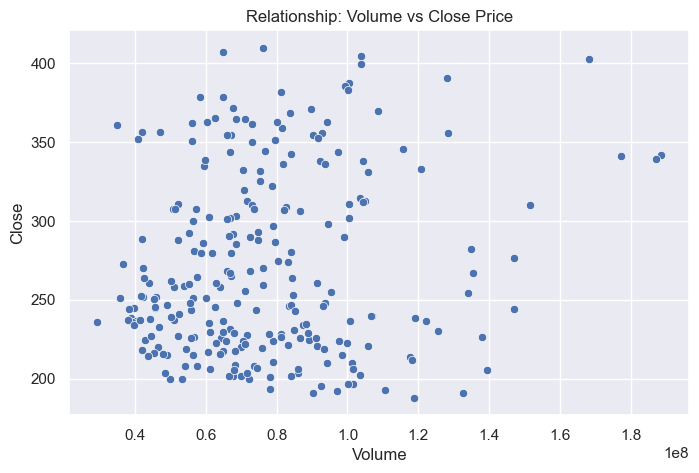

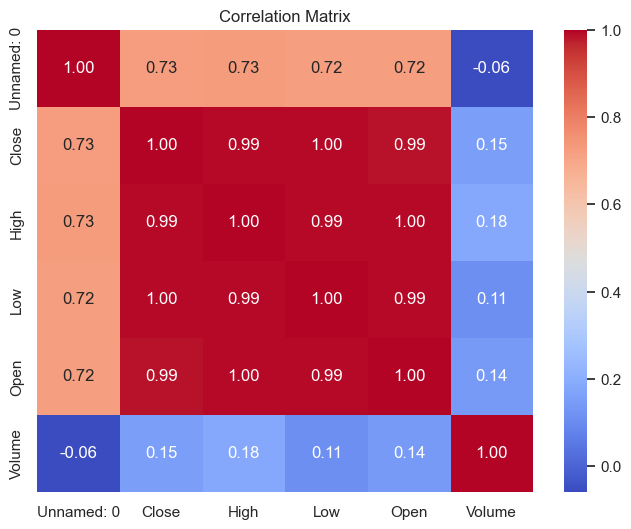

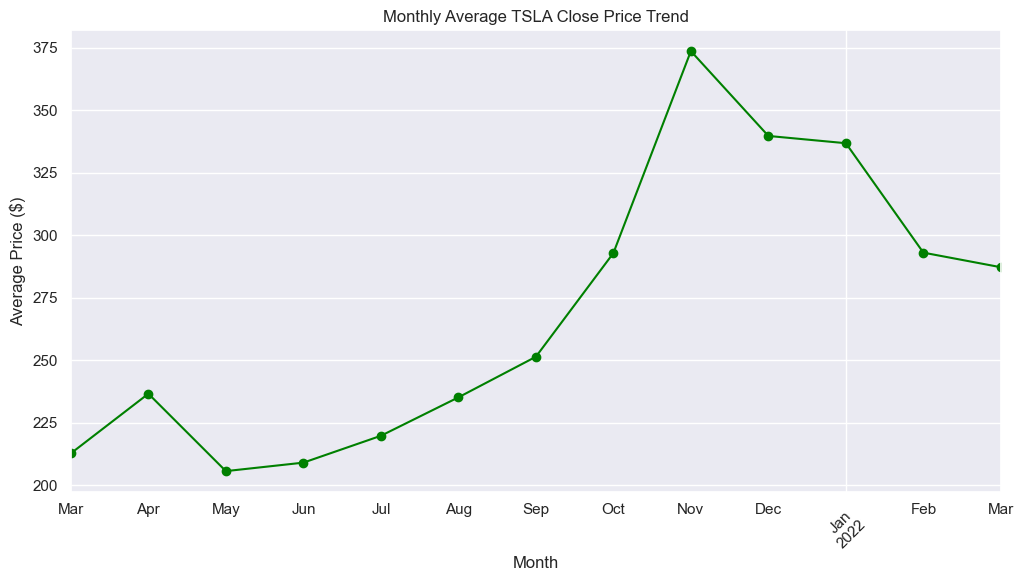

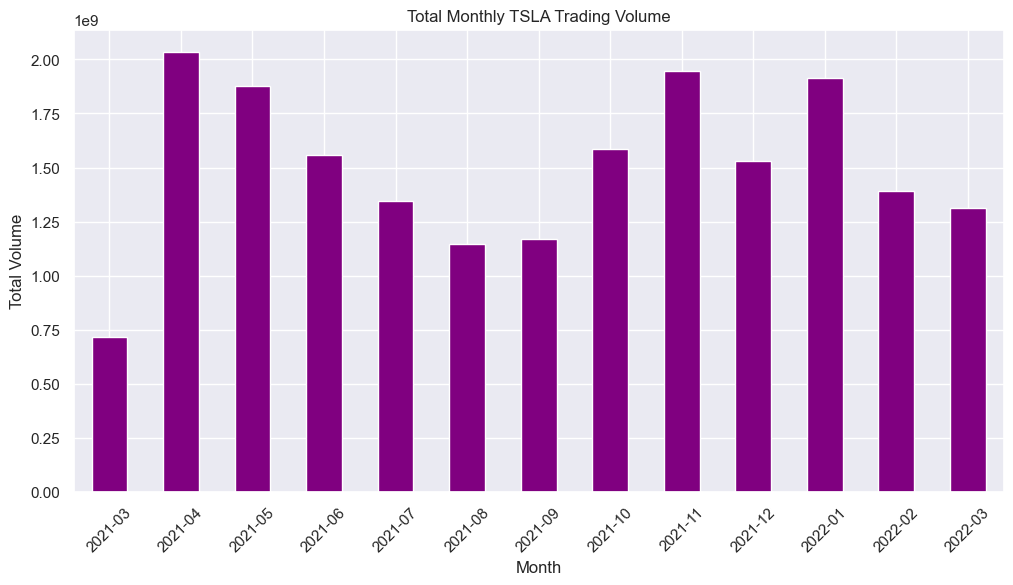

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

df = pd.read_csv('TSLA.csv')

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Initial Data Types ---")
print(df.dtypes)

df['Date'] = pd.to_datetime(df['Date'])

print("\n--- Data Types after Conversion ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isna().sum())

duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

print("\n--- Shape (rows, columns) ---")
print(f"Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n--- Statistical Summary ---")
print(df.describe(include='all'))

plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=20, kde=True)
plt.title("Distribution of TSLA Close Price")
plt.xlabel("Price ($)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Volume'], bins=20, kde=True, color='orange')
plt.title("Distribution of TSLA Trading Volume")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Volume', y='Close', data=df)
plt.title("Relationship: Volume vs Close Price")
plt.show()


plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


df['Month'] = df['Date'].dt.to_period('M')
monthly_avg_close = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(12,6))
monthly_avg_close.plot(marker='o', color='green')
plt.title("Monthly Average TSLA Close Price Trend")
plt.ylabel("Average Price ($)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

monthly_total_volume = df.groupby('Month')['Volume'].sum()

plt.figure(figsize=(12,6))
monthly_total_volume.plot(kind='bar', color='purple')
plt.title("Total Monthly TSLA Trading Volume")
plt.ylabel("Total Volume")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()